# EDA GitHub-репозиториев по темам AI и ML

Цель работы — изучить открытые GitHub-репозитории из поисковой выдачи по темам AI и ML и проверить, как связаны показатели популярности и активности проектов.

Данные представляют собой снимок поисковой выдачи на момент сбора. Число звёзд, форков и других метрик со временем меняется, поэтому результаты описывают именно эту выборку, а не весь GitHub.


## 1. Подготовка данных

Ноутбук использует готовую объединённую выгрузку из репозитория. Пути вычисляются относительно корня проекта, поэтому ручная настройка не требуется.


In [1]:
from pathlib import Path
import ast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "raw_concat_dataset").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "raw_concat_dataset" / "github_repositories.csv"
OUTPUT_PATH = PROJECT_ROOT / "new_index_dataset" / "github_repositories_new.csv"

df = pd.read_csv(DATA_PATH)
print(f"Загружено строк: {len(df):,}; признаков: {df.shape[1]}")
df.head(3)


Загружено строк: 1,953; признаков: 10


,Name,Description,Programming languages,Forks count,Stars count,Commits count,Pull requests count,Contributors count,Releases counts,Url
0,Significant-Gravitas AutoGPT,AutoGPT is the vision of accessible AI for eve...,"['Python', 'TypeScript', 'Dart', 'JavaScript',...",46180,180076,7606,86,783,83,https://github.com/Significant-Gravitas/AutoGPT
1,n8n-io n8n,Fair-code workflow automation platform with na...,"['TypeScript', 'Vue', 'SCSS', 'Python', 'JavaS...",51326,160338,16635,657,567,446,https://github.com/n8n-io/n8n
2,AUTOMATIC1111 stable-diffusion-webui,Stable Diffusion web UI,"['Python', 'JavaScript', 'CSS', 'HTML', 'Other']",29467,158707,7689,65,586,27,https://github.com/AUTOMATIC1111/stable-diffus...


Проверим типы, пропуски и дубликаты. Описания могут отсутствовать — для текстовых признаков заменим такие значения пустой строкой. Строки без URL исключим, потому что URL используется как идентификатор репозитория.


In [2]:
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique(dropna=True),
})
summary


,dtype,missing,unique
Name,object,0,1894
Description,object,0,1891
Programming languages,object,0,968
Forks count,int64,0,1108
Stars count,int64,0,1658
Commits count,int64,0,1168
Pull requests count,int64,0,171
Contributors count,int64,0,289
Releases counts,int64,0,245
Url,object,0,1894


In [3]:
def parse_languages(value):
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return value
    try:
        parsed = ast.literal_eval(str(value))
    except (ValueError, SyntaxError):
        return [str(value).strip()] if str(value).strip() else []
    return [str(item).strip() for item in parsed if str(item).strip()]


before = len(df)
df = (
    df.dropna(subset=["Url"])
      .drop_duplicates(subset=["Url"])
      .copy()
)
df["Description"] = df["Description"].fillna("")
df["Programming languages"] = df["Programming languages"].apply(parse_languages)

numeric_columns = [
    "Forks count", "Stars count", "Commits count", "Pull requests count",
    "Contributors count", "Releases counts",
]
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors="coerce").fillna(0)

print(f"Удалено дубликатов и строк без URL: {before - len(df)}")
print(f"Итоговый размер выборки: {len(df):,}")


Удалено дубликатов и строк без URL: 59
Итоговый размер выборки: 1,894


## 2. Распределение метрик

GitHub-метрики обычно имеют длинный правый хвост: небольшое число очень известных проектов сильно отличается от основной массы. Поэтому вместе со средним полезно смотреть медиану и квантили, а на графиках использовать логарифмическую шкалу.


In [4]:
df[numeric_columns].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).round(1).T


,count,mean,std,min,25%,50%,75%,90%,99%,max
Forks count,1894.0,1251.6,3716.4,0.0,147.0,424.0,1001.0,2619.8,13295.1,75030.0
Stars count,1894.0,7857.8,15105.9,305.0,758.5,3451.5,7741.5,18864.8,76160.0,192703.0
Commits count,1894.0,2065.8,8110.4,1.0,93.2,382.5,1519.2,4381.8,27913.0,200324.0
Pull requests count,1894.0,23.4,78.5,0.0,1.0,4.0,16.0,49.0,381.4,1866.0
Contributors count,1894.0,63.5,196.3,0.0,4.0,16.0,51.0,150.7,707.9,3812.0
Releases counts,1894.0,49.4,227.7,0.0,0.0,1.0,28.0,100.4,709.7,5000.0


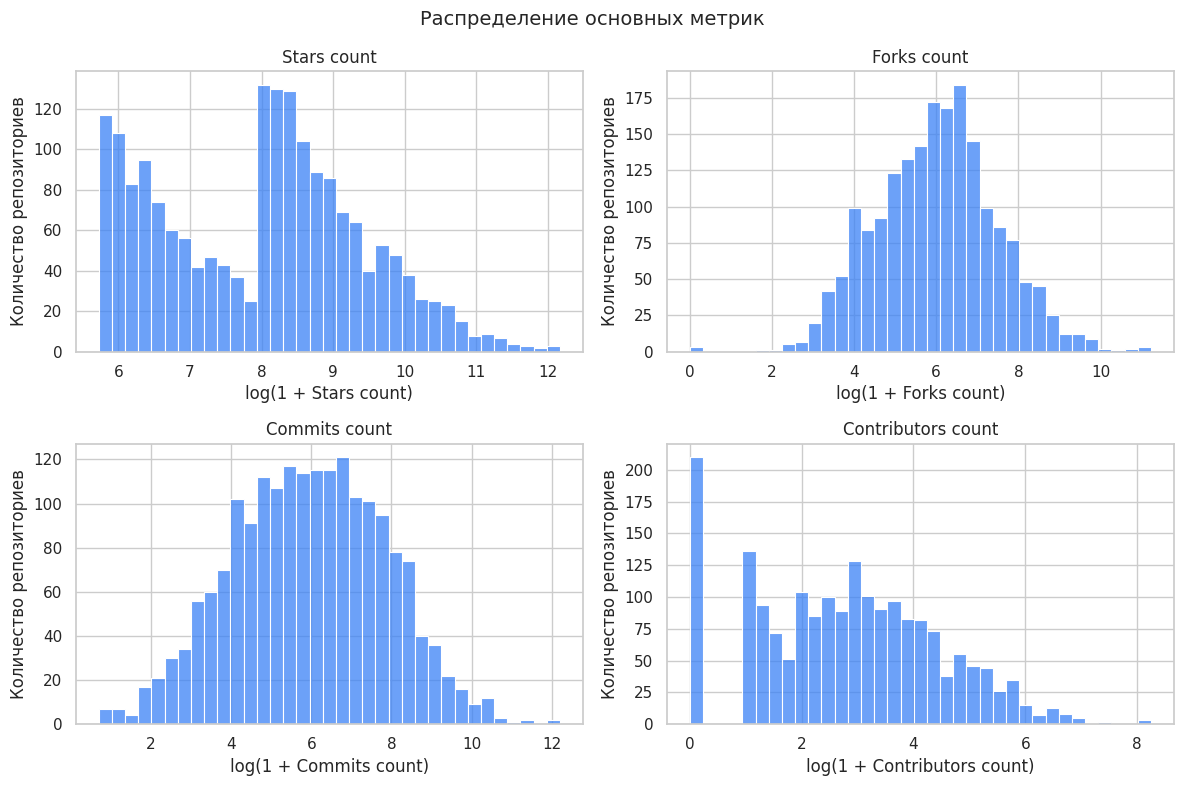

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, column in zip(axes.flat, ["Stars count", "Forks count", "Commits count", "Contributors count"]):
    sns.histplot(np.log1p(df[column]), bins=35, ax=ax, color="#3b82f6")
    ax.set_xlabel(f"log(1 + {column})")
    ax.set_ylabel("Количество репозиториев")
    ax.set_title(column)
fig.suptitle("Распределение основных метрик", fontsize=14)
plt.tight_layout()


## 3. Связь активности и популярности

Проверим ранговую корреляцию Спирмена. Она лучше линейной корреляции подходит для асимметричных распределений и показывает монотонную связь. Корреляция не доказывает причинность: например, звёзды и контрибьюторы могут одновременно расти с возрастом и известностью проекта.


,Stars count,Forks count,Commits count,Pull requests count,Contributors count,Releases counts
Stars count,1.00,0.88,0.45,0.49,0.56,0.36
Forks count,0.88,1.00,0.39,0.49,0.52,0.26
Commits count,0.45,0.39,1.00,0.54,0.80,0.64
Pull requests count,0.49,0.49,0.54,1.00,0.66,0.44
Contributors count,0.56,0.52,0.80,0.66,1.00,0.58
Releases counts,0.36,0.26,0.64,0.44,0.58,1.00


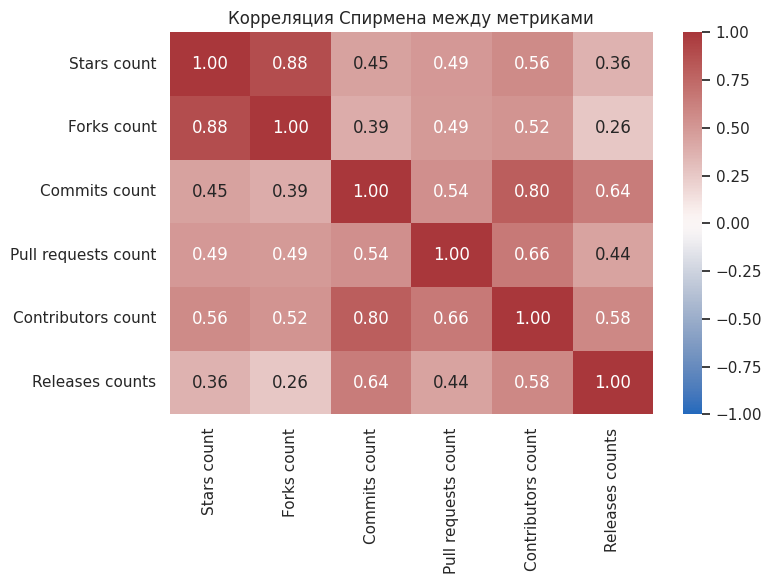

In [6]:
activity_columns = [
    "Stars count", "Forks count", "Commits count",
    "Pull requests count", "Contributors count", "Releases counts",
]
correlation = df[activity_columns].corr(method="spearman")

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1)
plt.title("Корреляция Спирмена между метриками")
plt.tight_layout()
correlation.round(2)


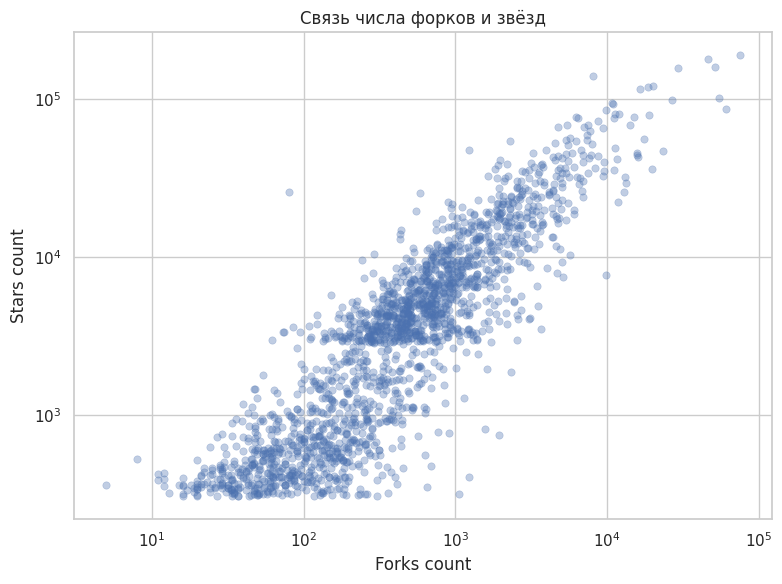

In [7]:
plot_df = df[(df["Stars count"] > 0) & (df["Forks count"] > 0)].copy()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x="Forks count",
    y="Stars count",
    alpha=0.35,
    s=28,
    edgecolor=None,
)
plt.xscale("log")
plt.yscale("log")
plt.title("Связь числа форков и звёзд")
plt.tight_layout()


## 4. Языки программирования

Один репозиторий может содержать несколько языков, поэтому развернём списки и посчитаем, в какой доле проектов встречается каждый язык. Это доля репозиториев, а не доля строк кода.


,share_percent
Programming languages,
Python,57.3
Other,36.8
Shell,25.4
JavaScript,25.3
TypeScript,22.3
Jupyter Notebook,19.3
HTML,16.4
CSS,15.9
Dockerfile,10.8


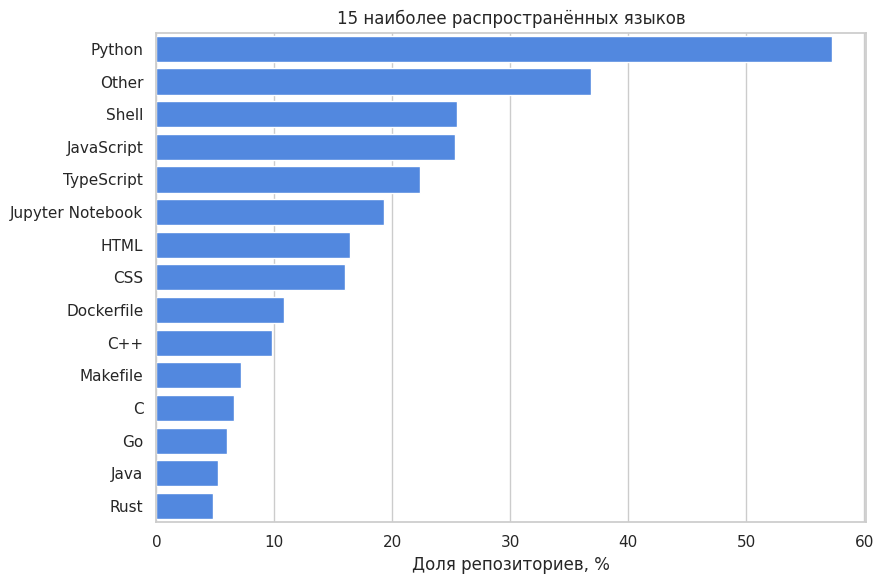

In [8]:
languages = (
    df[["Url", "Programming languages"]]
      .explode("Programming languages")
      .dropna(subset=["Programming languages"])
)
languages = languages[languages["Programming languages"] != ""]

language_share = (
    languages.groupby("Programming languages")["Url"].nunique()
             .div(len(df))
             .mul(100)
             .sort_values(ascending=False)
             .head(15)
)

plt.figure(figsize=(9, 6))
sns.barplot(x=language_share.values, y=language_share.index, color="#3b82f6")
plt.xlabel("Доля репозиториев, %")
plt.ylabel("")
plt.title("15 наиболее распространённых языков")
plt.tight_layout()
language_share.round(1).to_frame("share_percent")


## 5. Тематические слова в описаниях

Для небольшого текстового эксперимента отметим репозитории, в описании которых встречаются термины `LLM`, `agent`, `RAG`, `workflow` или `chatbot`. Сравнение носит описательный характер: группы различаются не только этими словами, поэтому результат нельзя трактовать как эффект ключевого слова на популярность.


In [9]:
keywords = ["llm", "agent", "rag", "workflow", "chatbot"]
pattern = r"\b(?:" + "|".join(keywords) + r")\b"
df["Mentions current AI terms"] = (
    df["Description"].str.lower().str.contains(pattern, regex=True, na=False)
)

keyword_comparison = (
    df.groupby("Mentions current AI terms")["Stars count"]
      .agg(repositories="size", median_stars="median", mean_stars="mean")
      .round(1)
)
keyword_comparison


,repositories,median_stars,mean_stars
Mentions current AI terms,,,
False,1672,3158.0,7109.8
True,222,6331.0,13491.5


## 6. Итоги

- Распределения активности сильно скошены: небольшая группа популярных проектов формирует длинный правый хвост.
- Число звёзд и форков связано наиболее заметно; это ожидаемо для двух показателей популярности одного проекта.
- Python входит в число самых часто встречающихся языков выборки, но многие репозитории используют несколько языков.
- Репозитории с актуальными AI-терминами в описании можно сравнить по медиане звёзд, однако такое наблюдение не позволяет делать причинный вывод.

Ограничения: выборка сформирована поиском GitHub по двум запросам, метрики являются снимком на момент сбора, а HTML-парсинг может пропускать отдельные значения. Для строгого исследования понадобились бы датированные выгрузки через GitHub API и повторные наблюдения во времени.


## 7. Экспорт подготовленной выборки

Сохраняем очищенные данные и несколько прозрачных производных признаков. Синтетические даты и признаки на их основе намеренно не создаются.


In [10]:
df["Languages count"] = df["Programming languages"].apply(len)
df["Stars per contributor"] = (
    df["Stars count"] / df["Contributors count"].replace(0, np.nan)
).round(2)
df["Programming languages"] = df["Programming languages"].apply(str)

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTPUT_PATH, index=False)
print(f"Сохранено: {OUTPUT_PATH.relative_to(PROJECT_ROOT)}")


Сохранено: new_index_dataset/github_repositories_new.csv
